In [18]:
pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load CSV
df = pd.read_csv("experiment2_results_combined.csv")

df.head()

,breakdown,group,n,Qwen2.5-7B_A_brier,Qwen2.5-7B_A_accuracy,Qwen2.5-7B_A_skill,Qwen2.5-7B_B_brier,Qwen2.5-7B_B_accuracy,Qwen2.5-7B_B_skill,Qwen2.5-7B_C_brier,...,Qwen2.5-14B_C_skill,Mistral-7B_A_brier,Mistral-7B_A_accuracy,Mistral-7B_A_skill,Mistral-7B_B_brier,Mistral-7B_B_accuracy,Mistral-7B_B_skill,Mistral-7B_C_brier,Mistral-7B_C_accuracy,Mistral-7B_C_skill
0,overall,all,709,0.957859,0.201693,-0.189448,1.039036,0.157969,-0.290252,0.959732,...,-0.169138,0.961483,0.162200,-0.193949,0.985609,0.145275,-0.223908,0.966022,0.156559,-0.199585
1,frame_type,book_context,211,0.876917,0.218009,-0.122946,0.968757,0.137441,-0.240553,0.884762,...,-0.112718,0.916022,0.137441,-0.173022,0.950975,0.118483,-0.217782,0.925824,0.127962,-0.185575
2,frame_type,passage_context,284,1.053683,0.105634,-0.297590,1.140666,0.084507,-0.404708,1.062933,...,-0.293417,1.027031,0.077465,-0.264770,1.080623,0.063380,-0.330766,1.041491,0.070423,-0.282576
3,frame_type,world_context,214,0.910497,0.313084,-0.109809,0.973458,0.275701,-0.186552,0.896693,...,-0.058841,0.919319,0.299065,-0.120562,0.893665,0.280374,-0.089292,0.905503,0.299065,-0.103721
4,reasoning_type,abstention,55,1.284686,0.109091,-0.567559,1.296449,0.109091,-0.581913,1.192533,...,-0.451225,1.233157,0.054545,-0.504684,1.013601,0.181818,-0.236784,1.186702,0.090909,-0.448001


In [9]:
# Melt correctly using your actual columns
df_long = df.melt(
    id_vars=["breakdown", "group", "n"],
    var_name="model_cond_metric",
    value_name="value"
)

# Split safely from the right
df_long[["model", "condition", "metric"]] = (
    df_long["model_cond_metric"]
    .str.rsplit("_", n=2, expand=True)
)

df_long.drop(columns=["model_cond_metric"], inplace=True)

df_long.head()

,breakdown,group,n,value,model,condition,metric
0,overall,all,709,0.957859,Qwen2.5-7B,A,brier
1,frame_type,book_context,211,0.876917,Qwen2.5-7B,A,brier
2,frame_type,passage_context,284,1.053683,Qwen2.5-7B,A,brier
3,frame_type,world_context,214,0.910497,Qwen2.5-7B,A,brier
4,reasoning_type,abstention,55,1.284686,Qwen2.5-7B,A,brier


In [10]:
print(df_long["model"].unique())
print(df_long["condition"].unique())
print(df_long["metric"].unique())
print(df_long["breakdown"].unique())

['Qwen2.5-7B' 'Qwen2.5-14B' 'Mistral-7B']
['A' 'B' 'C']
['brier' 'accuracy' 'skill']
['overall' 'frame_type' 'reasoning_type']


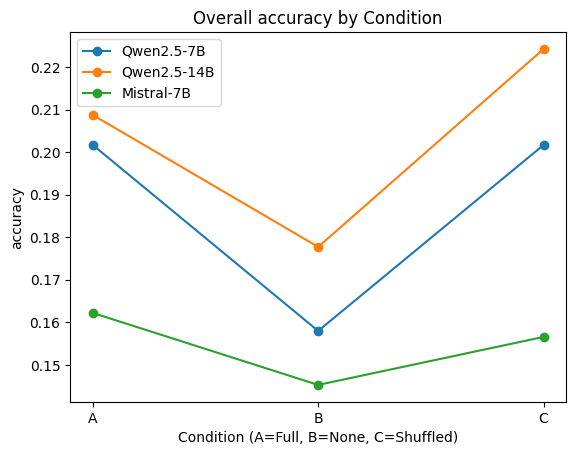

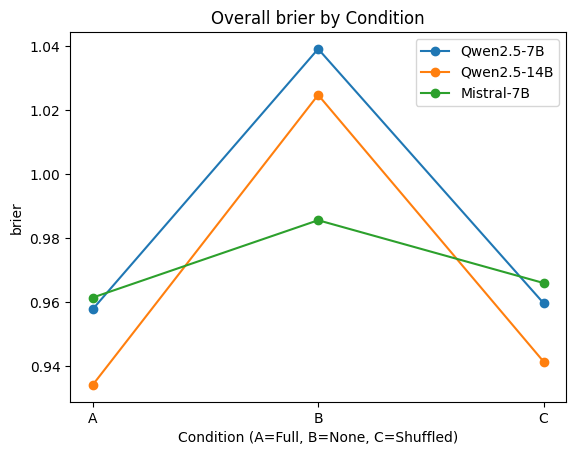

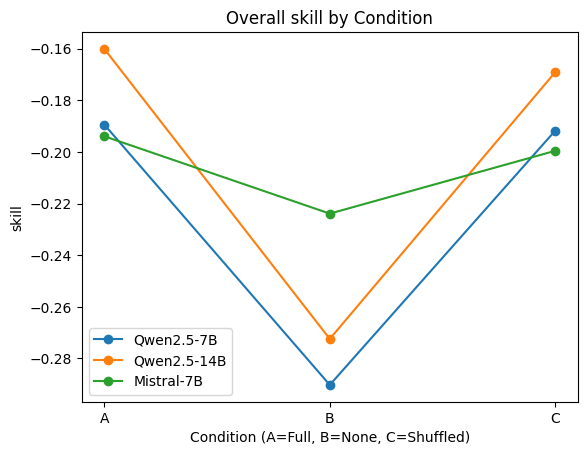

In [11]:
overall = df_long[df_long["breakdown"] == "overall"]

for metric in ["accuracy", "brier", "skill"]:
    plt.figure()
    
    for model in overall["model"].unique():
        subset = overall[
            (overall["model"] == model) & 
            (overall["metric"] == metric)
        ].sort_values("condition")
        
        plt.plot(subset["condition"], subset["value"], marker='o', label=model)
    
    plt.title(f"Overall {metric} by Condition")
    plt.xlabel("Condition (A=Full, B=None, C=Shuffled)")
    plt.ylabel(metric)
    plt.legend()
    plt.show()

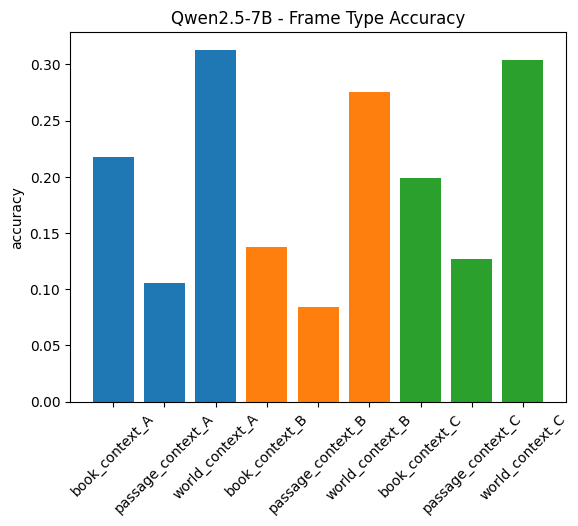

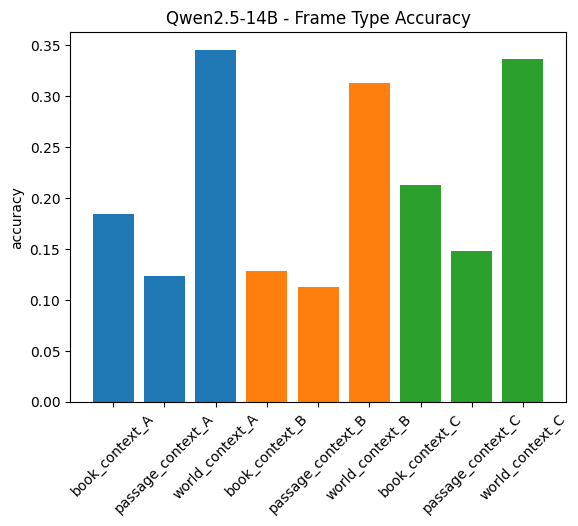

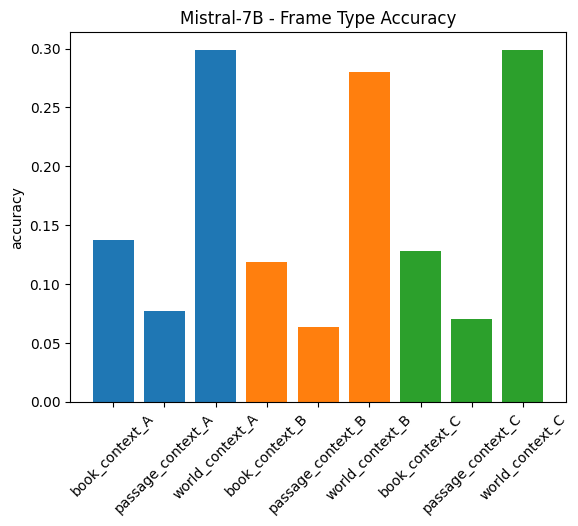

In [12]:
frame_df = df_long[df_long["breakdown"] == "frame_type"]

for model in frame_df["model"].unique():
    plt.figure()
    
    subset = frame_df[
        (frame_df["model"] == model) & 
        (frame_df["metric"] == "accuracy")
    ]
    
    for cond in ["A", "B", "C"]:
        cond_data = subset[subset["condition"] == cond]
        plt.bar(cond_data["group"] + f"_{cond}", cond_data["value"])
    
    plt.title(f"{model} - Frame Type Accuracy")
    plt.xticks(rotation=45)
    plt.ylabel("accuracy")
    plt.show()

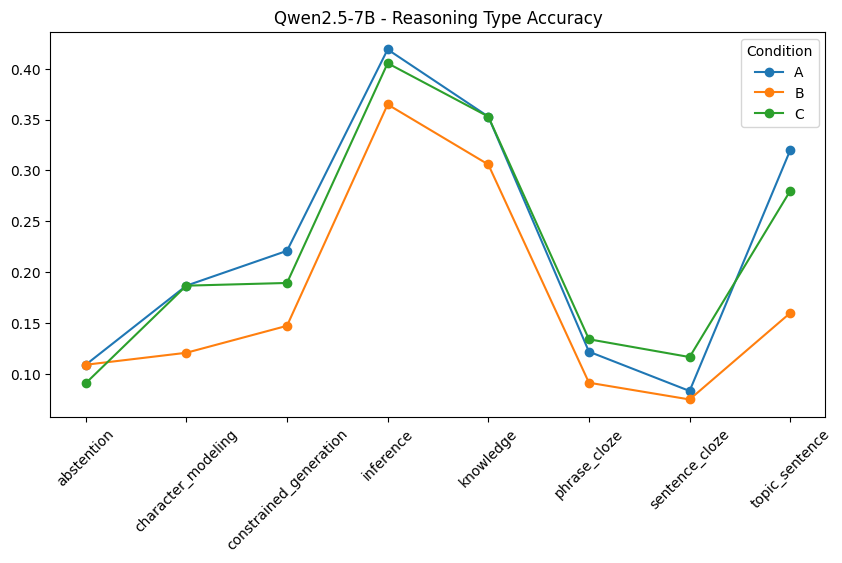

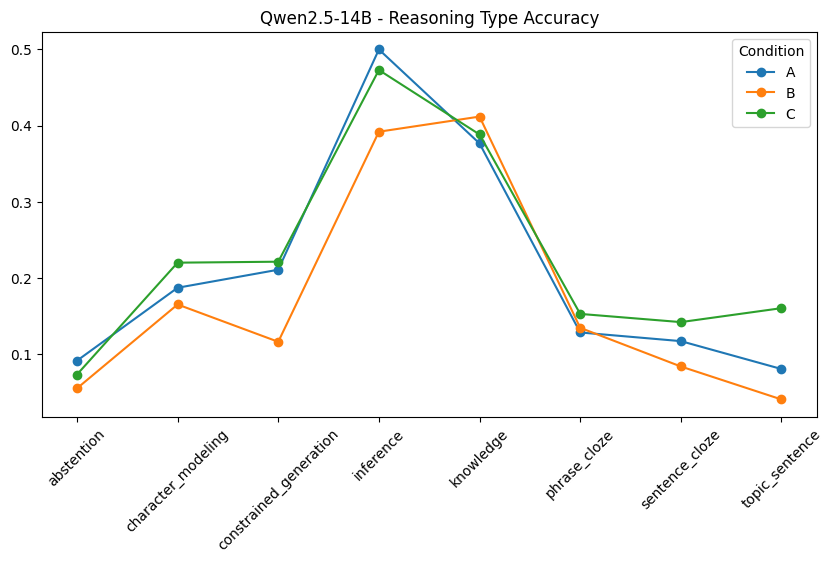

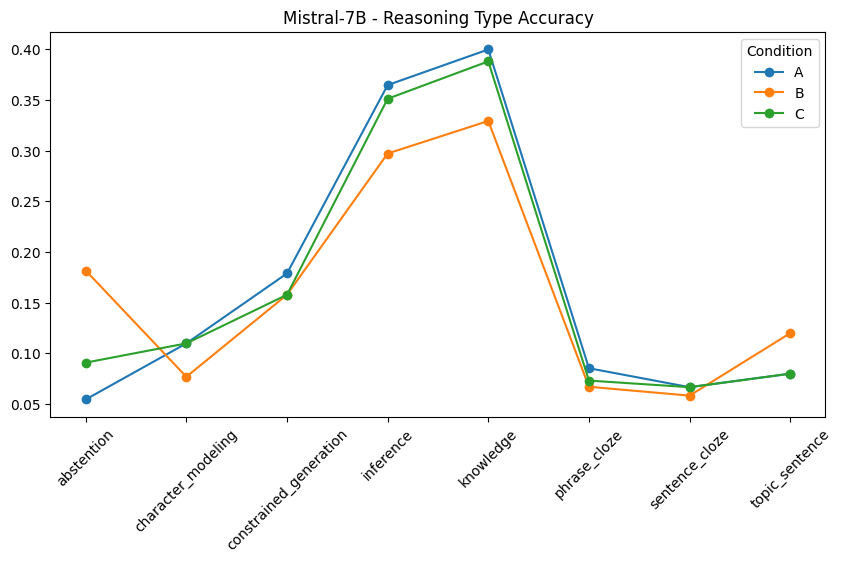

In [13]:
reason_df = df_long[df_long["breakdown"] == "reasoning_type"]

for model in reason_df["model"].unique():
    plt.figure(figsize=(10,5))
    
    subset = reason_df[
        (reason_df["model"] == model) & 
        (reason_df["metric"] == "accuracy")
    ]
    
    for cond in ["A", "B", "C"]:
        cond_data = subset[subset["condition"] == cond]
        plt.plot(cond_data["group"], cond_data["value"], marker='o', label=cond)
    
    plt.title(f"{model} - Reasoning Type Accuracy")
    plt.xticks(rotation=45)
    plt.legend(title="Condition")
    plt.show()

In [14]:
pivot = df_long.pivot_table(
    index=["breakdown", "group", "model", "metric"],
    columns="condition",
    values="value"
).reset_index()

# Effects
pivot["gain_A_vs_B"] = pivot["A"] - pivot["B"]
pivot["gain_C_vs_A"] = pivot["C"] - pivot["A"]

pivot.head()

condition,breakdown,group,model,metric,A,B,C,gain_A_vs_B,gain_C_vs_A
0,frame_type,book_context,Mistral-7B,accuracy,0.137441,0.118483,0.127962,0.018957,-0.009479
1,frame_type,book_context,Mistral-7B,brier,0.916022,0.950975,0.925824,-0.034953,0.009802
2,frame_type,book_context,Mistral-7B,skill,-0.173022,-0.217782,-0.185575,0.044760,-0.012552
3,frame_type,book_context,Qwen2.5-14B,accuracy,0.184834,0.127962,0.213270,0.056872,0.028436
4,frame_type,book_context,Qwen2.5-14B,brier,0.847659,0.952557,0.868930,-0.104898,0.021271


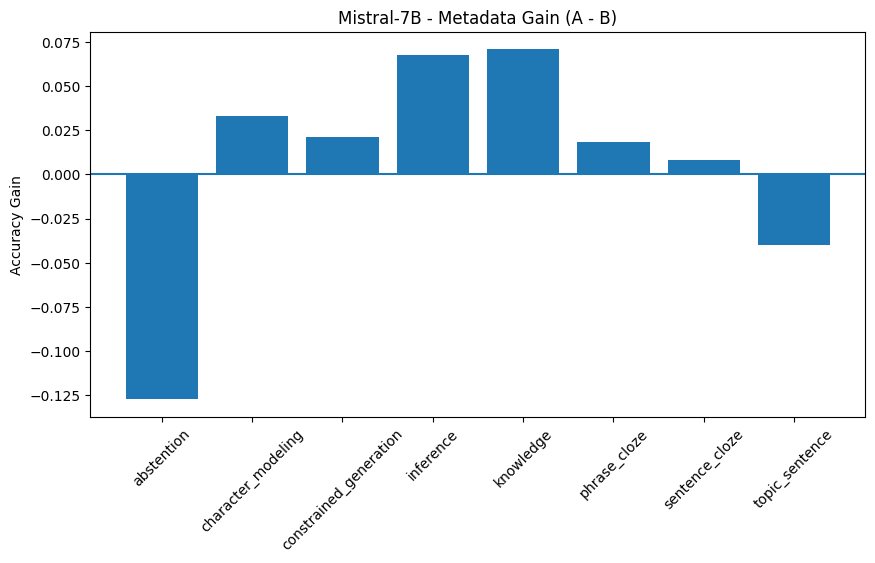

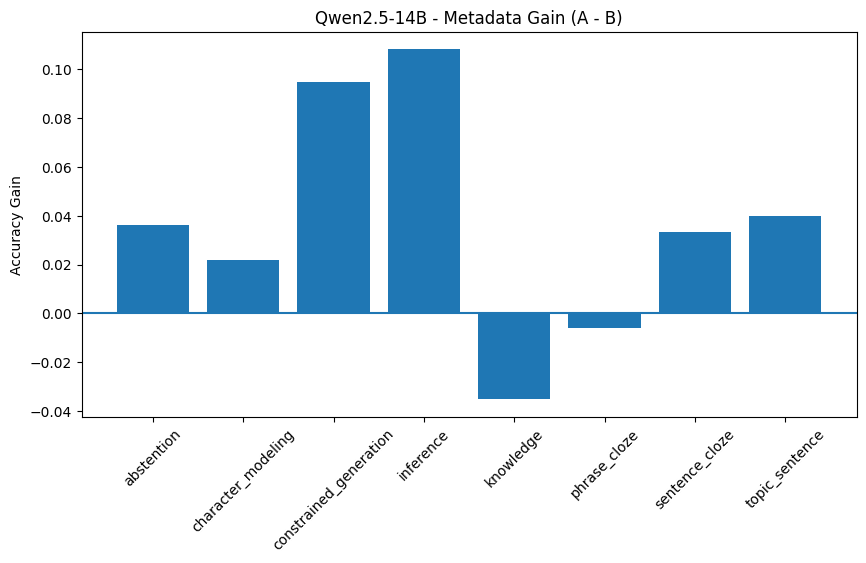

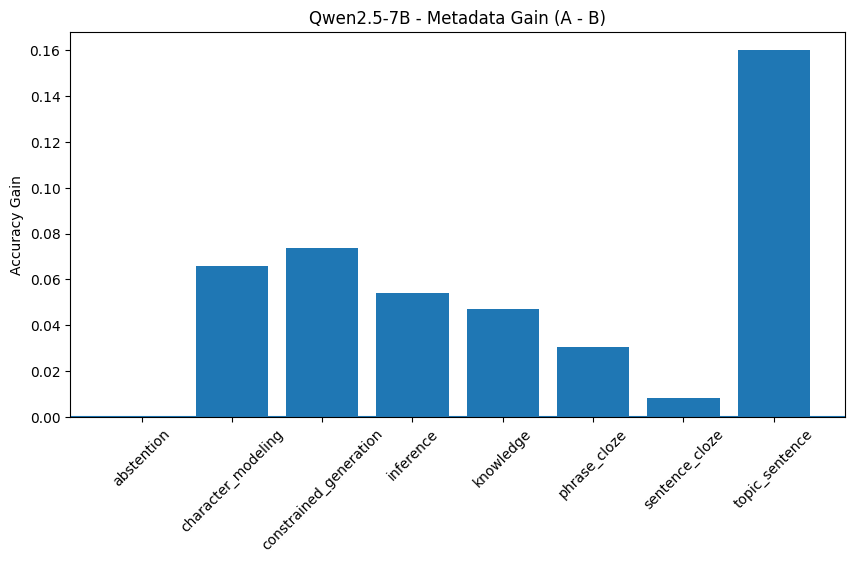

In [15]:
gain_df = pivot[
    (pivot["metric"] == "accuracy") & 
    (pivot["breakdown"] == "reasoning_type")
]

for model in gain_df["model"].unique():
    plt.figure(figsize=(10,5))
    
    subset = gain_df[gain_df["model"] == model]
    
    plt.bar(subset["group"], subset["gain_A_vs_B"])
    plt.axhline(0)
    
    plt.title(f"{model} - Metadata Gain (A - B)")
    plt.xticks(rotation=45)
    plt.ylabel("Accuracy Gain")
    plt.show()

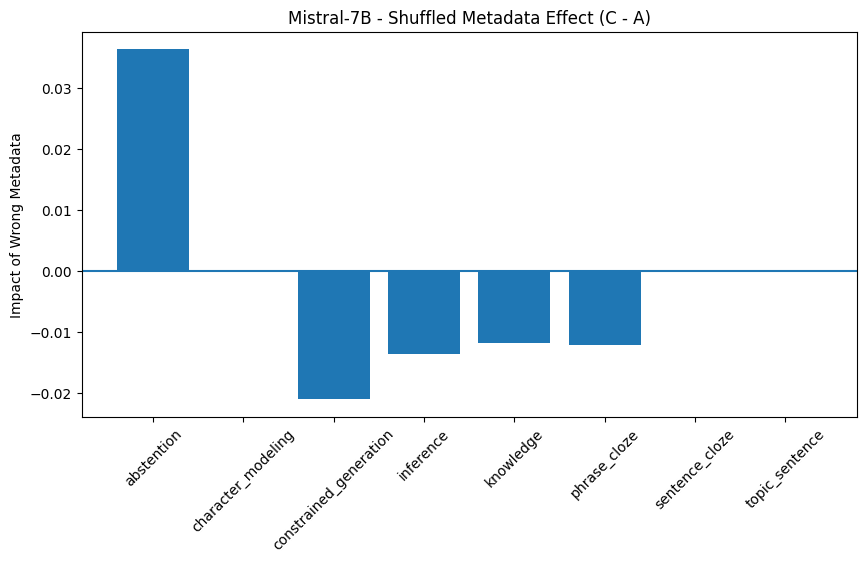

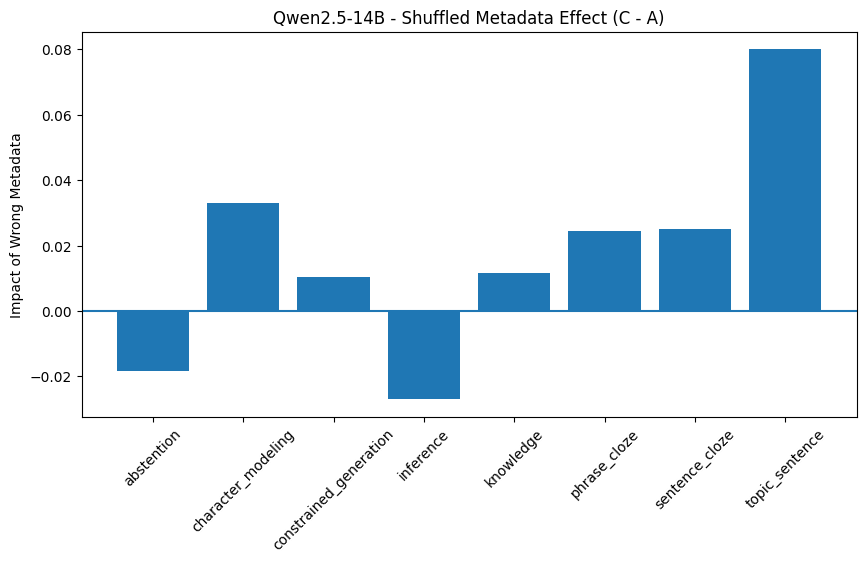

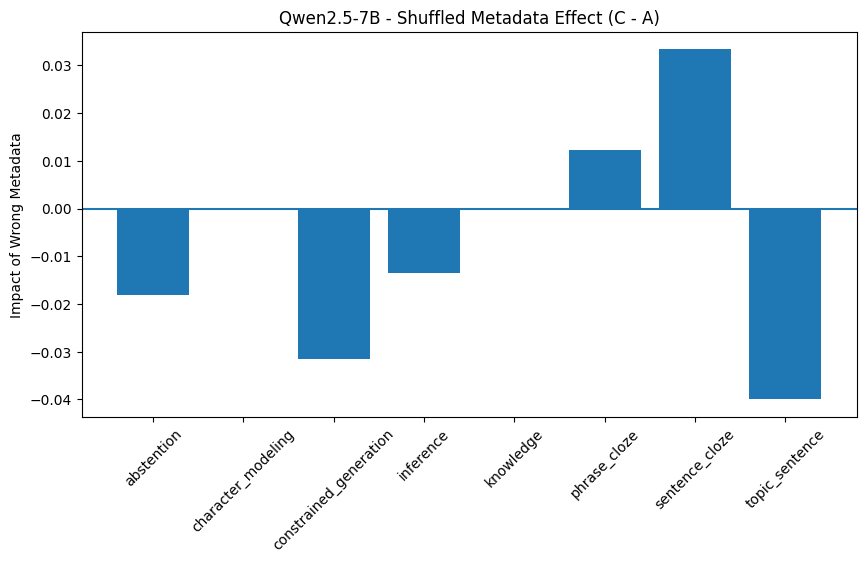

In [16]:
for model in gain_df["model"].unique():
    plt.figure(figsize=(10,5))
    
    subset = gain_df[gain_df["model"] == model]
    
    plt.bar(subset["group"], subset["gain_C_vs_A"])
    plt.axhline(0)
    
    plt.title(f"{model} - Shuffled Metadata Effect (C - A)")
    plt.xticks(rotation=45)
    plt.ylabel("Impact of Wrong Metadata")
    plt.show()

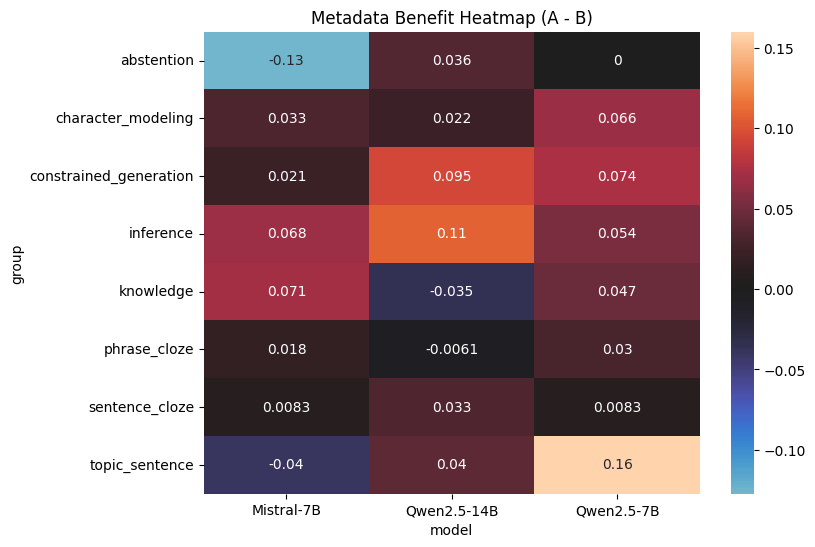

In [20]:


heat = gain_df.pivot(index="group", columns="model", values="gain_A_vs_B")

plt.figure(figsize=(8,6))
sns.heatmap(heat, annot=True, center=0)
plt.title("Metadata Benefit Heatmap (A - B)")
plt.show()

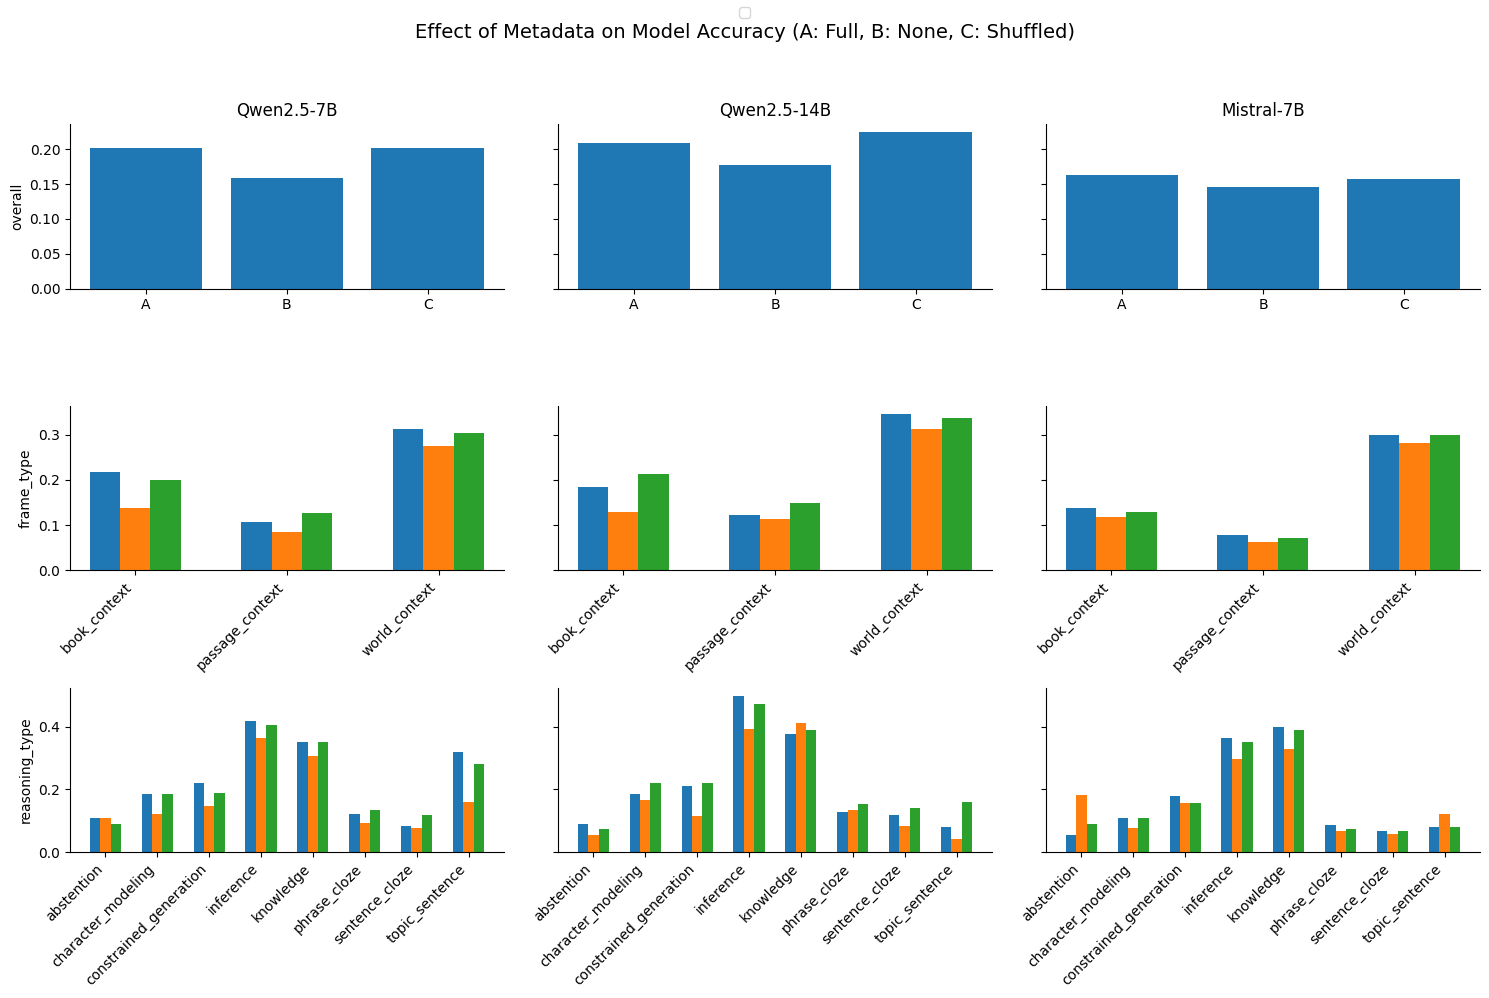

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load + reshape (same as before) ---
df1 = pd.read_csv("experiment2_results_combined.csv")

df1_long = df1.melt(
    id_vars=["breakdown", "group", "n"],
    var_name="model_cond_metric",
    value_name="value"
)

df1_long[["model", "condition", "metric"]] = (
    df1_long["model_cond_metric"]
    .str.rsplit("_", n=2, expand=True)
)

df1_long.drop(columns=["model_cond_metric"], inplace=True)

df1_long["condition"] = pd.Categorical(
    df1_long["condition"],
    categories=["A", "B", "C"],
    ordered=True
)

# --- Filter for accuracy only ---
df1_acc = df1_long[df1_long["metric"] == "accuracy"]

models = df1_acc["model"].unique()
breakdowns = ["overall", "frame_type", "reasoning_type"]

# --- Create subplot grid ---
fig, axes = plt.subplots(
    nrows=len(breakdowns),
    ncols=len(models),
    figsize=(15, 10),
    sharey="row"
)

# --- Plot ---
for i, breakdown in enumerate(breakdowns):
    for j, model in enumerate(models):
        ax = axes[i, j]
        
        subset = df1_acc[
            (df1_acc["breakdown"] == breakdown) &
            (df1_acc["model"] == model)
        ]
        
        if breakdown == "overall":
            # Single bar group
            data = subset.sort_values("condition")
            ax.bar(data["condition"], data["value"])
            ax.set_xticks(range(len(data["condition"])))
            ax.set_xticklabels(data["condition"])
        
        else:
            # Grouped bars
            groups = subset["group"].unique()
            x = range(len(groups))
            width = 0.2
            
            for k, cond in enumerate(["A", "B", "C"]):
                cond_data = subset[subset["condition"] == cond]
                cond_data = cond_data.set_index("group").loc[groups]
                
                ax.bar(
                    [p + k*width for p in x],
                    cond_data["value"],
                    width=width,
                    label=cond if i == 0 else None
                )
            
            ax.set_xticks([p + width for p in x])
            ax.set_xticklabels(groups, rotation=45, ha="right")
        
        # Titles
        if i == 0:
            ax.set_title(model)
        if j == 0:
            ax.set_ylabel(breakdown)
        
        # Clean look
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# Legend (top center)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.suptitle("Effect of Metadata on Model Accuracy (A: Full, B: None, C: Shuffled)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()